## NREL Supply Solar Supply Curves 2030

In [1]:
# Edit all the Mardown cells below with the appropriate information 
# Run all cells, containing your code 
# Save this Jupyter with the outputs of your executed cells
# PS: Save again the notebook with this outcome.
# PSPS: Don't forget to include the dataset in your submission

**Team:**
* Christina Perez DeHaro

**Course:** CISD 43 – BIG DATA (Spring, 2026)

# Problem Statement
* My project aims to analyze the NREL Limited Access 2030 Moderate PV 
Supply Curve dataset that is produced by NREL’s reV (Renewable Energy 
Potential) Models. The goal is to identify patterns in solar development 
costs across California and evaluate which site characteristics most influence 
LCOE (Levelized Cost Of Energy).
    
    
    
* **Keywords:** Linear Regression, NREL, KNN, NREL Limited Access 2030 Moderate PV Supply Curves
	

## Required packages

* Add instructions to install the required packages


In [15]:
#! pip install pymongo

In [17]:
# Run on correct numpy version if necessary
# import subprocess
# subprocess.run(["pip", "install", "numpy<2", "--quiet"])

In [19]:
#Import the Necessary Libararies Packages 

import pandas as pd
from pymongo import MongoClient
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Methodology

1. Data is ingested and stored in MongoDB, followed by Exploratory Data Analysis (EDA) to profile LCOE distributions across California counties. Two machine learning models are then trained and evaluated



2. Introduce the topics you used in your project
 * Model 1
    * Linear Regression
 
 * Model 2
    * KNN
 

## Connect to dataset hosted in MongoDB

In [23]:
client = MongoClient('mongodb://localhost:27017/')

In [25]:
db = client["testing"]

In [27]:
collection = db["nrel"]

In [29]:
# Retrieve the first three records
result = collection.find().limit(5)

# Print the records
for record in result:
    print(record)

{'_id': ObjectId('6a23b308710edabdd297a94a'), 'area_sq_km': 1.204307940673828, 'capacity_mw_ac': 38.64570449377158, 'capacity_mw_dc': 51.7852414489746, 'cnty_fips': 53073, 'country': 'United States', 'county': 'Whatcom', 'dist_km': 0.9963961030678928, 'elevation': 23.2, 'latitude': 48.994, 'lcot': 41.386483384381776, 'longitude': -122.735, 'mean_cf_ac': 0.19883126, 'mean_cf_dc': 0.14838155, 'mean_lcoe': 59.87425709754124, 'mean_res': 3.377832, 'reg_mult': 1.0187303, 'reinforcement_cost_per_mw_ac': 813613.0513085702, 'reinforcement_dist_km': 229.4184349193356, 'sc_point_gid': 416, 'state': 'Washington', 'timezone': -8, 'total_lcoe': 101.26074048192302, 'trans_cap_cost_per_mw_ac': 77430.2111570799}
{'_id': ObjectId('6a23b308710edabdd297a94b'), 'area_sq_km': 0.8135640197753906, 'capacity_mw_ac': 26.10690640918063, 'capacity_mw_dc': 34.9832528503418, 'cnty_fips': 53055, 'country': 'United States', 'county': 'San Juan', 'dist_km': 14.00491557497398, 'elevation': 32.8, 'latitude': 49.022, 'l

# EDA

## Create dataframe for data within the state of California

In [33]:
query = {'state': "California"}

result = collection.find(query)

# Convert the result to a pandas DataFrame
df = pd.DataFrame(list(result))

# Display the DataFrame
print(df)

                           _id  area_sq_km  capacity_mw_ac  capacity_mw_dc  \
0     6a23b30b710edabdd297d8ea    0.203472        6.529325        8.749296   
1     6a23b30b710edabdd297da12    0.684612       21.968892       29.438317   
2     6a23b30b710edabdd297da13    1.606716       51.558794       69.088788   
3     6a23b30b710edabdd297da14    1.082808       34.746824       46.560747   
4     6a23b30b710edabdd297da15    0.016524        0.530248        0.710532   
...                        ...         ...             ...             ...   
2755  6a23b311710edabdd2985cf7   65.553945     2103.596587     2818.819621   
2756  6a23b311710edabdd2985cf8   59.255064     1901.468099     2547.967732   
2757  6a23b311710edabdd2985df7    2.258280       72.467186       97.106036   
2758  6a23b311710edabdd2985ef5   13.585076      435.939039      584.158284   
2759  6a23b311710edabdd2985fec    3.486564      111.882284      149.922253   

      cnty_fips        country     county     dist_km   elevati

In [40]:
df.head()

,_id,area_sq_km,capacity_mw_ac,capacity_mw_dc,cnty_fips,country,county,dist_km,elevation,latitude,...,mean_lcoe,mean_res,reg_mult,reinforcement_cost_per_mw_ac,reinforcement_dist_km,sc_point_gid,state,timezone,total_lcoe,trans_cap_cost_per_mw_ac
0,6a23b30b710edabdd297d8ea,0.203472,6.529325,8.749296,6015,United States,Del Norte,61.683266,125.333333,41.986,...,50.717754,4.120177,1.081992,1.422906e+06,376.101552,25466,California,-8,639.162709,1.429827e+07
1,6a23b30b710edabdd297da12,0.684612,21.968892,29.438317,6015,United States,Del Norte,8.809403,56.666667,41.893,...,52.247262,4.062002,1.084387,1.781207e+06,256.980915,25846,California,-8,160.864954,1.040914e+06
2,6a23b30b710edabdd297da13,1.606716,51.558794,69.088788,6015,United States,Del Norte,11.803890,285.625000,41.921,...,50.355025,4.175112,1.083833,1.781207e+06,256.980915,25847,California,-8,126.485579,2.702859e+05
3,6a23b30b710edabdd297da14,1.082808,34.746824,46.560747,6015,United States,Del Norte,13.337636,607.909091,41.950,...,48.237379,4.398418,1.083631,1.695098e+06,241.641441,25848,California,-8,128.883800,5.731362e+05
4,6a23b30b710edabdd297da15,0.016524,0.530248,0.710532,6015,United States,Del Norte,37.876299,630.000000,41.978,...,48.489174,4.466510,1.083503,1.905410e+06,273.703922,25849,California,-8,4044.898673,1.099016e+08


In [42]:
df.tail()

,_id,area_sq_km,capacity_mw_ac,capacity_mw_dc,cnty_fips,country,county,dist_km,elevation,latitude,...,mean_lcoe,mean_res,reg_mult,reinforcement_cost_per_mw_ac,reinforcement_dist_km,sc_point_gid,state,timezone,total_lcoe,trans_cap_cost_per_mw_ac
2755,6a23b311710edabdd2985cf7,65.553945,2103.596587,2818.819621,6025,United States,Imperial,251.184279,105.214286,32.763,...,33.831718,5.981142,1.006305,61542.478002,8.724701,66550,California,-8,80.468533,1.697601e+06
2756,6a23b311710edabdd2985cf8,59.255064,1901.468099,2547.967732,6025,United States,Imperial,263.129792,78.937500,32.783,...,33.992068,5.928655,1.001099,61542.478002,8.724701,66551,California,-8,79.295824,1.632027e+06
2757,6a23b311710edabdd2985df7,2.258280,72.467186,97.106036,6025,United States,Imperial,21.180429,31.000000,32.647,...,34.355245,5.942000,1.008530,863592.131349,310.095260,66929,California,-7,65.388867,2.912543e+05
2758,6a23b311710edabdd2985ef5,13.585076,435.939039,584.158284,6025,United States,Imperial,27.895799,32.428571,32.550,...,33.978806,5.987235,1.007868,796323.046671,302.103350,67309,California,-7,61.994083,2.571834e+05
2759,6a23b311710edabdd2985fec,3.486564,111.882284,149.922253,6025,United States,Imperial,32.676584,36.333333,32.453,...,33.505549,6.063752,1.007602,796323.046671,302.103350,67689,California,-7,64.855774,3.989861e+05


In [38]:
df.shape

(2760, 24)

In [26]:
df.columns

Index(['_id', 'area_sq_km', 'capacity_mw_ac', 'capacity_mw_dc', 'cnty_fips',
       'country', 'county', 'dist_km', 'elevation', 'latitude', 'lcot',
       'longitude', 'mean_cf_ac', 'mean_cf_dc', 'mean_lcoe', 'mean_res',
       'reg_mult', 'reinforcement_cost_per_mw_ac', 'reinforcement_dist_km',
       'sc_point_gid', 'state', 'timezone', 'total_lcoe',
       'trans_cap_cost_per_mw_ac'],
      dtype='object')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2760 entries, 0 to 2759
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   _id                           2760 non-null   object 
 1   area_sq_km                    2760 non-null   float64
 2   capacity_mw_ac                2760 non-null   float64
 3   capacity_mw_dc                2760 non-null   float64
 4   cnty_fips                     2760 non-null   int64  
 5   country                       2760 non-null   object 
 6   county                        2760 non-null   object 
 7   dist_km                       2760 non-null   float64
 8   elevation                     2760 non-null   float64
 9   latitude                      2760 non-null   float64
 10  lcot                          2760 non-null   float64
 11  longitude                     2760 non-null   float64
 12  mean_cf_ac                    2760 non-null   float64
 13  mea

In [32]:
df.isnull().sum()

_id                             0
area_sq_km                      0
capacity_mw_ac                  0
capacity_mw_dc                  0
cnty_fips                       0
country                         0
county                          0
dist_km                         0
elevation                       0
latitude                        0
lcot                            0
longitude                       0
mean_cf_ac                      0
mean_cf_dc                      0
mean_lcoe                       0
mean_res                        0
reg_mult                        0
reinforcement_cost_per_mw_ac    0
reinforcement_dist_km           0
sc_point_gid                    0
state                           0
timezone                        0
total_lcoe                      0
trans_cap_cost_per_mw_ac        0
dtype: int64

In [34]:
df.describe()

,area_sq_km,capacity_mw_ac,capacity_mw_dc,cnty_fips,dist_km,elevation,latitude,lcot,longitude,mean_cf_ac,mean_cf_dc,mean_lcoe,mean_res,reg_mult,reinforcement_cost_per_mw_ac,reinforcement_dist_km,sc_point_gid,timezone,total_lcoe,trans_cap_cost_per_mw_ac
count,2760.000000,2760.000000,2760.000000,2760.000000,2760.000000,2760.000000,2760.000000,2760.000000,2760.000000,2760.000000,2760.000000,2760.000000,2760.000000,2760.000000,2.760000e+03,2760.000000,2760.000000,2760.000000,2760.000000,2.760000e+03
mean,10.905117,349.940318,468.920051,6057.818116,68.918144,755.161993,37.320631,905.512590,-119.899466,0.317791,0.237157,40.027005,5.362782,1.094312,1.615526e+06,219.216679,46057.171377,-7.998188,945.539595,3.065064e+07
std,15.730126,504.772674,676.395437,29.817256,80.246043,635.452926,2.630430,9564.095750,2.414509,0.024384,0.018197,3.681153,0.410331,0.029894,1.193975e+06,157.570814,11248.656686,0.042532,9563.946920,3.419234e+08
min,0.000324,0.010397,0.013932,6001.000000,0.217279,-67.700000,32.453000,4.818287,-124.376000,0.233982,0.174613,33.439612,3.995288,0.996734,1.251062e+04,1.483675,25466.000000,-8.000000,43.944464,1.881313e+04
25%,0.759456,24.370601,32.656611,6029.000000,14.075339,198.822802,35.080750,47.174913,-121.727500,0.300482,0.224241,37.039122,5.059412,1.082489,5.442686e+05,87.576130,36107.750000,-8.000000,85.917675,4.336908e+05
50%,3.441042,110.421494,147.964803,6057.000000,31.306847,594.750000,37.229000,69.938112,-120.304000,0.314997,0.235072,40.491866,5.335262,1.094145,1.635948e+06,195.228389,46374.500000,-8.000000,109.871546,9.334887e+05
75%,15.002416,481.420748,645.103885,6081.000000,100.551807,1229.791667,39.621250,124.397697,-118.089500,0.338322,0.252479,42.443800,5.697159,1.108492,2.318046e+06,328.005401,55508.250000,-8.000000,165.616347,1.916579e+06
max,98.033984,3145.865672,4215.461295,6115.000000,522.221655,2668.000000,41.998000,317542.381412,-114.205000,0.365014,0.272398,53.886997,6.129000,1.197262,6.181621e+06,992.546246,67689.000000,-7.000000,317582.748783,1.096335e+10


## Exploritory Plots


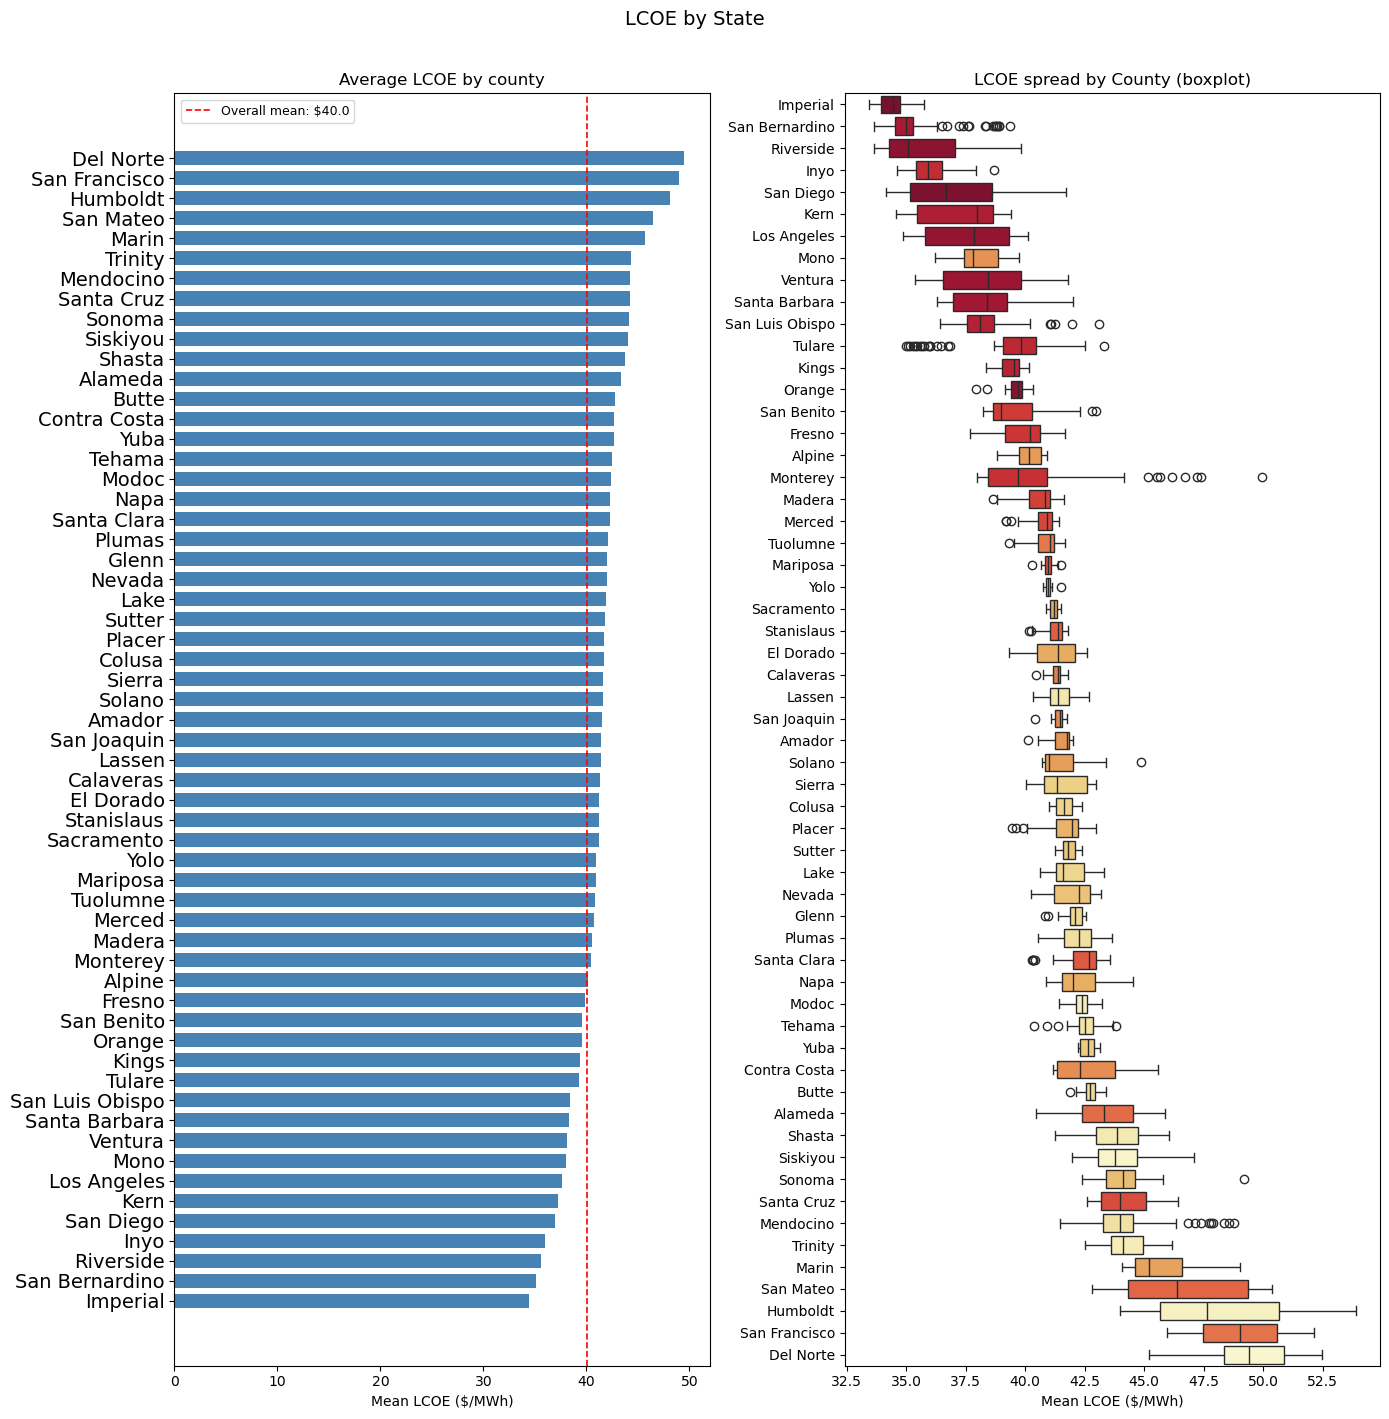

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 14))
fig.suptitle('LCOE by State', fontsize=14, y=1.01)

lcoe_order = df.groupby('county')['mean_lcoe'].mean().sort_values().index

# ── left: barplot with error bars ─────────────────────────────────────────
# — left: barplot by county
ax = axes[0]

# Calculate mean LCOE per county in order
county_means = df.groupby('county')['mean_lcoe'].mean().reindex(lcoe_order)

ax.barh(range(len(lcoe_order)), county_means.values, color='steelblue', height=0.7)
ax.set_yticks(range(len(lcoe_order)))
ax.set_yticklabels(lcoe_order, fontsize=14)
ax.axvline(df['mean_lcoe'].mean(), color='red', linestyle='--', linewidth=1.2,
           label=f"Overall mean: ${df['mean_lcoe'].mean():.1f}")
ax.set_xlabel('Mean LCOE ($/MWh)')
ax.set_ylabel('')
ax.set_title('Average LCOE by county')
ax.legend(fontsize=9)

# ── right: boxplot shows spread ───────────────────────────────────────────
ax2 = axes[1]
sns.boxplot(data=df, x='mean_lcoe', y='county', order=lcoe_order,
            hue='county', palette='YlOrRd', legend=False)
ax2.set_xlabel('Mean LCOE ($/MWh)')
ax2.set_ylabel('')
ax2.set_title('LCOE spread by County (boxplot)')

plt.tight_layout()
plt.savefig('plot4_lcoe_by_state.png', bbox_inches='tight')
plt.show()

Del Norte, San Francisco and Humboldt Counties have the highest LCOE Averages indicating that total cost is higher to build in these counties.
Imperial, San Bernardino, and Riverside have the lowest LCOE Averages indicates that the total cost to build is likely more favorable here.

San Berdaino, Tulare, Mendocino and Monterey have a number of outliers suggesting that there are more specific areas within the couties that have much lower or higher LCOE scores. This could suggest variability in site suitability for the area. 

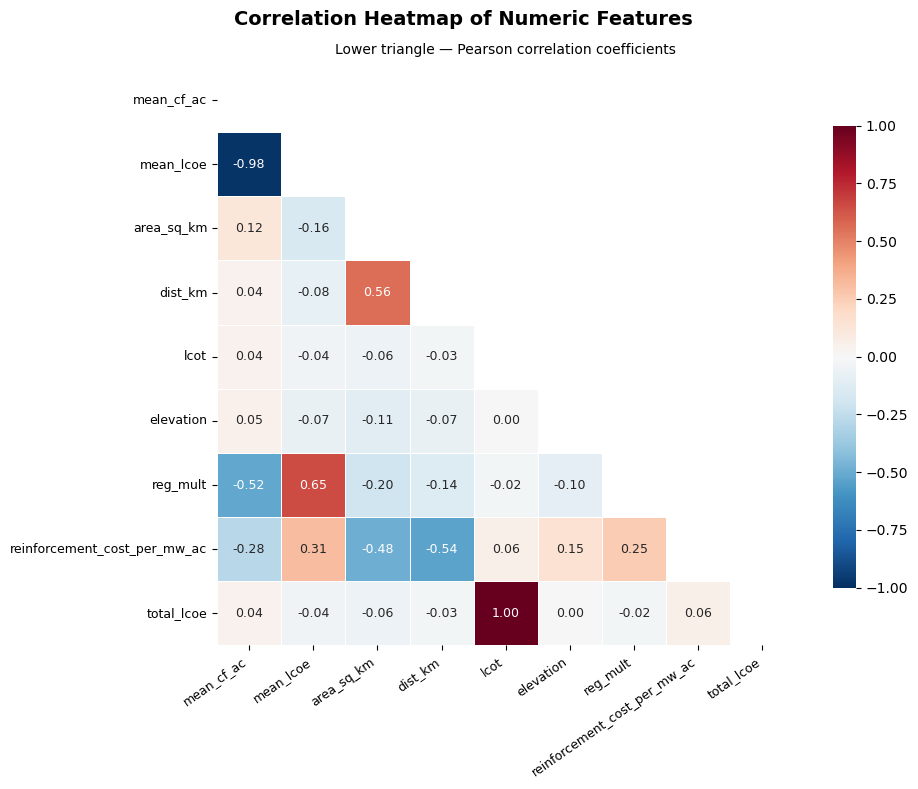

In [46]:
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')

num_cols = [
    'mean_cf_ac', 'mean_lcoe', 'capacity_mw', 'area_sq_km',
    'dist_km', 'lcot', 'elevation', 'reg_mult',
    'reinforcement_cost_per_mw_ac','total_lcoe'

]

# only keep columns that exist in your dataframe
num_cols = [c for c in num_cols if c in df.columns]
corr = df[num_cols].corr()

# lower triangle mask
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax,
            annot_kws={'size': 9})
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_title('Lower triangle — Pearson correlation coefficients', fontsize=10, pad=10)

plt.tight_layout()
plt.savefig('plot7_correlation_heatmap.png', bbox_inches='tight')
plt.show()

Mean_af_ac (Capacity Factor) & Mean_lcoe(Avg. Levalized Cost of Energy) have a negative correlation score of -0.98 suggesting that sites with higher solar energy outputs lower the overall cost of energy.

reg_mult (regional cost multiplier) and reinforcement_cost_per_mw_ac (cost to upgrade the existing grid infrastructure) have the highest correlation scores suggesting what region of the county and how far from the line to be most closely correlated with high LCOE scores

# Machine Learning 

# Linear Regression

In [122]:
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [124]:
# X = df.data  # Features
# y = df.target  # Target variable

In [126]:
X = df[['mean_cf_ac','mean_cf_dc','dist_km','elevation','reg_mult','reinforcement_cost_per_mw_ac','lcot']]

In [128]:
y = df['mean_lcoe']

In [130]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [132]:
model = LinearRegression()

In [134]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [136]:
y_pred = model.predict(X_test)

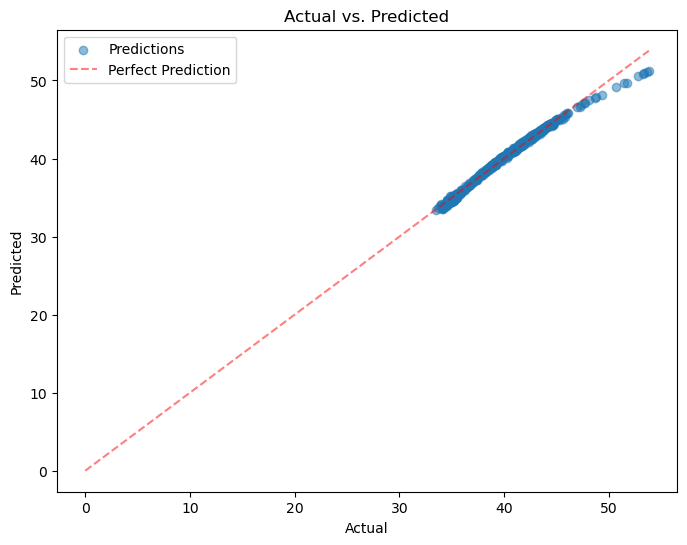

In [138]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, label='Predictions')
plt.plot([0, max(y_test)], [0, max(y_test)], '--r', alpha=0.5, label='Perfect Prediction')
plt.title('Actual vs. Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.show()

In [140]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.13650324005314005


In [142]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE:  0.2303
MSE:  0.1365
RMSE: 0.3695


The Actual vs prediction line is closely aligned sggesting that the linear regression model is highely accurate. With slightely less accuracy near the higher LCOE scores

MAE of 0.23 indicates that on average the models predction were off by $0.23 LCOE

MSE of 0.1365 indicates a low squared error, meaning no large outliers in the predictions

RMSE of 0.3695 which means the average prediction error is around $0.37 LCOE




# K-Nearest Neighbors (KNN)

KNN Regression Results (k=5, normalized)
  MAE:  0.2100
  MSE:  0.1542
  RMSE: 0.3927
  R²:   0.9883


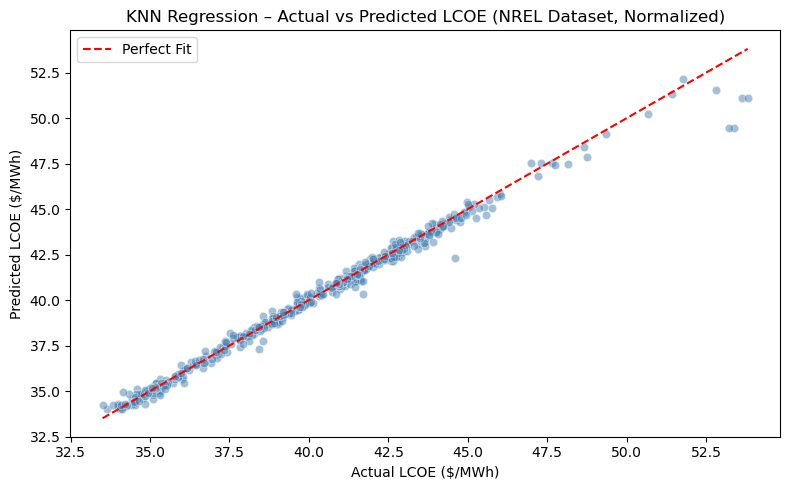

In [173]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Normalize Features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # transform only on test

# --- KNN Regression ---
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_scaled, y_train)
y_pred_knn = knn_reg.predict(X_test_scaled)

# --- Metrics ---
mae  = mean_absolute_error(y_test, y_pred_knn)
mse  = mean_squared_error(y_test, y_pred_knn)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_knn)

print("KNN Regression Results (k=5, normalized)")
print(f"  MAE:  {mae:.4f}")
print(f"  MSE:  {mse:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  R²:   {r2:.4f}")

# --- Actual vs Predicted Plot ---
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred_knn, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=1.5, label='Perfect Fit')
plt.xlabel("Actual LCOE ($/MWh)")
plt.ylabel("Predicted LCOE ($/MWh)")
plt.title("KNN Regression – Actual vs Predicted LCOE (NREL Dataset, Normalized)")
plt.legend()
plt.tight_layout()
plt.show()

### Conclusions


Both models perform  well overall

KNN has a slightly lower MAE (better on average error) but higher RMSE (worse on larger errors) — meaning KNN is more consistent in the middle range but linear regression handles outliers better

###  References
   - Academic (if any)
   - Online (if any)
	

Module 13 Example 4: House Price Prediction using KNN and GBR

Module 13 Example 3: Linear Regression to predict MPG and Car Prices

Module 13 Example 6: MongoDB - NBA dataset

### Credits

- If you use and/or adapt your code from existing projects, you must provide links and acknowldge the authors. 
> *This code is based on .... (if any)*

https://github.com/lukalee/CISD-43-Big-Data-Modeling-Analysis/blob/11f9e916a3e0fed154f3a4ecec6934654b9dd6f3/FinalProject/2%20CISD%2043%20-%20Project-%20Code.ipynb 

In [ ]:
# End of Project